# Predicting nanomotif parameters given rheological data

Prediction of fraction of bound sticky ends required for a given set of G' and G'' curves

Training data from simulations or from theoretical graphs of materials

Predictions use Gaussian process models for zero shot prediction or Bayesian optimization

In [1]:
%load_ext autoreload
%autoreload 2

# Import

In [2]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import readdy
import math
import scipy
import pandas as pd
import sklearn
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
import contextlib
import io
import pickle
import torch
from botorch.models import SingleTaskGP
from botorch.models.transforms import Normalize, Standardize
from botorch.fit import fit_gpytorch_mll
from gpytorch.mlls import ExactMarginalLogLikelihood
from gpytorch.likelihoods import FixedNoiseGaussianLikelihood
from botorch.acquisition import LogExpectedImprovement
from botorch.acquisition import ExpectedImprovement
from botorch.acquisition import UpperConfidenceBound
from botorch.optim import optimize_acqf
import multiprocessing

from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_percentage_error,mean_squared_log_error,mean_absolute_error
import threading
from concurrent.futures import ThreadPoolExecutor
from scipy.interpolate import interp1d
import torch

import sys
import os
import seaborn as sns
#sys.path.append(os.path.abspath(os.path.join('..', 'python_scripts')))

from NCG_readdy_sim_4 import Debye_length, Debye_Hueckel_pot_rep_strength ,Diff_at23C,visc_T,Diff_ES

from NCG_readdy_sim_4 import run_sim_3,tcl_file_gen_3,all_types

from NCG_Bay_opt_readdy_sim_3 import run_p,run_p_dict,gt_1_3,gt_1_1,gt_1_2,gt_1_4, cg_angle_distr_c1_4_ba_aa_oa_la,cg_angle_distr_c1_1_hp,cg_angle_distr_c1_1_bm, eval_sim_c1_1_la,eval_sim_c1_1_hp,eval_sim_c1_1_aa,eval_sim_c1_2_ba_oa, eval_sim_c1_4_ba_aa_oa_la,eval_sim_c1_1_bm,apply_gp, run_gp_11

from NCG_Bay_opt_readdy_sim_3 import gen_all_comb_from_list_of_lists_2

from NCG_readdy_sim_eval_3 import *
from NCG_theo_graphs_1 import *

#from NCG_readdy_sim_eval_1 import get_particle_number_from_sims
#from NCG_readdy_sim_eval_2 import get_time_avg_storage_loss_mod_2, get_subgraph_eigenvalues, relax_times, storage_mod, loss_mod_deref,relaxation_mod,get_time_avg_storage_loss_mod_4,get_subgraph_eigenvalues,get_time_avg_storage_loss_mod

> **Note on file paths and data availability**
>
> This notebook was originally run on the author's local machine and contains **absolute file paths**
> (e.g. `/home/aaron/...`, `/mnt/d/...`) pointing to simulation output, trajectory, and target-angle files.
> These paths will need to be updated to match your own local folder structure before the notebook can be
> run as-is.
>
> The simulation data referenced throughout this notebook (oxDNA, ReaDDy) is available on Zenodo:
> **https://zenodo.org/records/20022811**
>
> For a shorter, self-contained walkthrough of the overall workflow using local relative paths, see
> `tutorial_workflow.ipynb` in this repository.

# Functions

In [3]:
#for GP parameter values need to be in other range, for instance [0,5], apply scaler to parameter lists
def rescaled_params_df(df):
    scalers = []
    scaled_values = []

    for values in df['Param values']:
        scaler = MinMaxScaler(feature_range=(0, 5))
        scaled = scaler.fit_transform(np.asarray(values*10**20).reshape(-1, 1)).flatten()
        scalers.append(scaler)
        scaled_values.append(scaled)

    df['Scalers'] = scalers
    df['Rs param values'] = scaled_values
    
    return df

#generate linearly scaled rs values, independent of actual parameter scaling
def rescaled_params_2_df(df):
    scalers = []
    scaled_values = []

    for values in df['Param values']:
        scaler = MinMaxScaler(feature_range=(0, 5))
        values_lin=np.linspace(0,5,len(values))
        scaled = scaler.fit_transform(values_lin.reshape(-1, 1)).flatten()
        scalers.append(scaler)
        scaled_values.append(scaled)

    df['Scalers'] = scalers
    df['Rs param values'] = scaled_values
    
    return df

#place holder rescaling
def rescaled_params_no_sc_df(df):
    scalers = []
    scaled_values = []

    for values in df['Param values']:
        scaler = FunctionTransformer(func=None) #MinMaxScaler(feature_range=(0, 5))
        scaled = scaler.fit_transform(np.asarray(values).reshape(-1, 1)).flatten()
        scalers.append(scaler)
        scaled_values.append(scaled)

    df['Scalers'] = scalers
    df['Rs param values'] = scaled_values
    
    return df


def scale_by_inverse_min(X):
    min_vals = np.min(X, axis=0)
    return X * (1 / min_vals)

#sklearn scaler struggles with small values, use simple implementaion generated with Copilot
class MinMaxScaler2:
    def __init__(self):
        self.data_min = None
        self.data_max = None

    def fit(self, data):
        """
        Compute the minimum and maximum values for scaling.

        Parameters:
        data (numpy.ndarray): The input data to be scaled.
        """
        self.data_min = np.min(data, axis=0)
        self.data_max = np.max(data, axis=0)

    def transform(self, data):
        """
        Scale the data to the range [0, 1].

        Parameters:
        data (numpy.ndarray): The input data to be scaled.

        Returns:
        numpy.ndarray: The scaled data.
        """
        if self.data_min is None or self.data_max is None:
            raise ValueError("The scaler has not been fitted yet.")
        scaled_data = (data - self.data_min) / (self.data_max - self.data_min)
        return scaled_data

    def inverse_transform(self, scaled_data):
        """
        Reverse the scaling of the data.

        Parameters:
        scaled_data (numpy.ndarray): The scaled data to be reverted.

        Returns:
        numpy.ndarray: The original data.
        """
        if self.data_min is None or self.data_max is None:
            raise ValueError("The scaler has not been fitted yet.")
        original_data = scaled_data * (self.data_max - self.data_min) + self.data_min
        return original_data
        
#apply MinMaxScaler2 to data
def rescaled_params_df_MinMaxScaler2(df):
    scalers = []
    scaled_values = []

    for values in df['Param values']:
        scaler = MinMaxScaler2()
        scaler.fit(np.asarray(values).reshape(-1, 1))
        scaled = scaler.transform(np.asarray(values).reshape(-1, 1)).flatten()
        scalers.append(scaler)
        scaled_values.append(scaled)

    df['Scalers'] = scalers
    df['Rs param values'] = scaled_values
    
    return df

#use botorch implementation 
#initialize GP model, train on input and predict next params
def apply_gp_bo_sp(x,f,seed,dim_x,dim_y,num_restarts,raw_samples):

    #set random seed for torch and numpy, each round gets different seed based on number of rounds
    torch.manual_seed(seed+len(f))
    np.random.seed(seed+len(f))

    #fit scaler on full range of values
    #scaler_x1=scaler_x()
    #scaler_x1.fit(x) 
    #x=scaler_x1.transform(x)
    #print(x)
    #minimum and maximum values for bounds
    min_bounds = np.min(x, axis=0)
    max_bounds = np.max(x, axis=0)
    bounds = np.vstack((min_bounds, max_bounds))
    #print(bounds)
    bounds = torch.from_numpy(bounds)
    #print(x_train_rs,f_train_rs)

    #x and f as arrays
    x=np.array(x).reshape(-1,1)
    f=np.array(f).reshape(-1,1)

    #x and f as torch tensor
    x=torch.from_numpy(x)
    f=torch.from_numpy(f)
    
    #print(x_train_rs.shape,f_train_rs.shape)
    #option to specify noise
    #train_fvar = torch.zeros_like(f)  # Zero noise
    #likelihood = FixedNoiseGaussianLikelihood(noise=train_fvar)
    #gp=SingleTaskGP(train_X=x_train_rs,train_Y=f_train_rs,**params_SingleTaskGP_dict)
    #gp=SingleTaskGP(train_X=x,train_Y=f,train_Yvar=train_fvar,input_transform=Normalize(d=dim_x),outcome_transform=Standardize(m=dim_y))
    gp=SingleTaskGP(train_X=x,train_Y=f,input_transform=Normalize(d=dim_x),outcome_transform=Standardize(m=dim_y))
    

    mll = ExactMarginalLogLikelihood(gp.likelihood, gp)
    fit_gpytorch_mll(mll)

    logEI = LogExpectedImprovement(model=gp, best_f=f.max())
    ei = ExpectedImprovement(model=gp, best_f=f.max())
    ucb =UpperConfidenceBound(gp, beta=1)

    candidate, acq_value = optimize_acqf(ei, bounds=bounds, q=1, num_restarts=num_restarts, raw_samples=raw_samples)

    x_next=candidate.detach().numpy()[0]
  
    #gpr=None
    
    return x_next, gp




# Load in simulations

In [4]:
#example sim 


#load saved config
traj_mech=readdy.Trajectory("/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_shear_mod_2/prod_checkpoint_0/x_c_mech_opt_prod_0.h5")

times_mech,types_mech,ids_mech,part_positions_mech=traj_mech.read_observable_particles()
time_pt_mech, counts_pt_mech = traj_mech.read_observable_number_of_particles()
#part_pos_eq=part_positions

time_e_mech, energy_mech=traj_mech.read_observable_energy()

time_obs_top_mech,obs_top_mech=traj_mech.read_observable_topologies()

In [5]:
##Target###
#unbinding rate =0.0001
#binding rate=0.03
folder_name_sp1=["/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_shear_mod_inv_1/prod_checkpoint_"+str(e)+"/x_c_mech_opt_prod_"+str(e)+".h5" for e in [0,1,2,3,4]]


####Training data####
#unbinding rate =0.005
#binding rate=0.03
folder_name_sp2=["/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_shear_mod_inv_2/prod_checkpoint_"+str(e)+"/x_c_mech_opt_prod_"+str(e)+".h5" for e in [0,1,2,3,4]]

#unbinding rate =0.0005
#binding rate=0.03
folder_name_sp3=["/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_shear_mod_inv_3/prod_checkpoint_"+str(e)+"/x_c_mech_opt_prod_"+str(e)+".h5" for e in [0,1,2,3,4]]

#unbinding rate =0.00005
#binding rate=0.03
folder_name_sp4=["/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_shear_mod_inv_4/prod_checkpoint_"+str(e)+"/x_c_mech_opt_prod_"+str(e)+".h5" for e in [0,1,2,3,4]]


#unbinding rate =0.000005
#binding rate=0.03
folder_name_sp5=["/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_shear_mod_inv_5/prod_checkpoint_"+str(e)+"/x_c_mech_opt_prod_"+str(e)+".h5" for e in [0,1,2,3,4]]


In [6]:

# List of input parameter tuples
inputs_part_num = [(folder_name_sp1, [31,33,35,37]),(folder_name_sp2, [31,33,35,37]),(folder_name_sp3, [31,33,35,37]), (folder_name_sp4, [31,33,35,37]), (folder_name_sp5, [31,33,35,37])]

# Run in parallel

with ThreadPoolExecutor(max_workers=12) as executor:
    results_part_num = list(executor.map(lambda args: get_particle_number_from_sims2(*args), inputs_part_num))





0.735 0.0037416573867739417
0.474 0.007402702209328699
0.62 0.01019803902718557
0.767 0.007823042886243178
0.9 0.004242640687119285


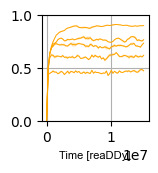

In [8]:
fused_linkers_ex_all=[results_part_num[e] for e in [0,1,2,3,4] ] #[fused_linkers_ex1,fused_linkers_ex2,fused_linkers_ex3,fused_linkers_ex4,fused_linkers_ex4]

rates_ub_ex_all=[r"$r_{Split}=0.0001$",r"$r_{Split}=5\cdot 10^{-3}$",r"$r_{Split}=5\cdot 10^{-4}$",r"$r_{Split}=5\cdot 10^{-5}$",r"$r_{Split}=5\cdot 10^{-6}$"]

fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))

for i in range(len(fused_linkers_ex_all)):  
    #fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
    #fig=plt.figure(figsize=(5,5))

    mean_fused_linkers=np.mean(fused_linkers_ex_all[i],axis=0)/400
    std_e_fused_linkers=np.std(fused_linkers_ex_all[i],axis=0)/(np.sqrt(fused_linkers_ex_all[i].shape[0])*400)
    print(mean_fused_linkers[-1],std_e_fused_linkers[-1])
    
    plt.errorbar(time_pt_mech[::50],mean_fused_linkers[::50],label=rates_ub_ex_all[i],color="orange",linewidth=0.7)
    plt.fill_between(time_pt_mech[::50], mean_fused_linkers[::50] + std_e_fused_linkers[::50], mean_fused_linkers[::50] - std_e_fused_linkers[::50], alpha = 0.3 ,facecolor="orange")

    fs1=8
    plt.xlabel("Time [reaDDy]",fontname = "Arial",fontsize=fs1)
    plt.grid()
    plt.ylim(0,1)
    #plt.xscale("log")

    save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/fraction_bound_sticky_ends_"+str(i)+"_1.pdf"
    #plt.savefig(save_name_1,format="pdf",bbox_inches="tight")
    #plt.show()


In [7]:

#print(np.mean(np.mean(fused_linkers_ex_all[0],axis=0)[2250:],axis=0)/400)
#print(np.std(np.mean(fused_linkers_ex_all[0],axis=0)[2250:],axis=0)/(400*np.sqrt(5)))

mean_fused_linkers_sp=[np.mean(np.mean(fused_linkers_ex_all[e],axis=0)[2250:],axis=0)/400 for e in range(5)]
print(mean_fused_linkers_sp)

stde_fused_linkers_sp=[np.mean(np.std(fused_linkers_ex_all[e],axis=0)[2250:],axis=0)/(400*np.sqrt(len(fused_linkers_ex_all[e]))) for e in range(5)]
print(stde_fused_linkers_sp)

[0.713687083888149, 0.46906524633821567, 0.6135632490013314, 0.7705286284953395, 0.8996764314247669]
[0.00877780926418587, 0.007796124546730789, 0.009132190919370509, 0.009106333445043692, 0.003351789754059565]


In [8]:
omega_t_sim1=np.geomspace(10**-3,10**5,10**3) #geomspace(10**2,10**10,10**3)
t_sim1=np.geomspace(10**-2,10**3,10**2)


folder_names_dyn_mod_sp=[folder_name_sp1,folder_name_sp2,folder_name_sp3,folder_name_sp4,folder_name_sp5,]
time_skip_dyn_mod_sp=[2250,2250,2250,2250,2250,2250]
#print(folder_names_dyn_mod)
input_dyn_mod_sp=[]
for i in range(len(folder_names_dyn_mod_sp)):
    input_dyn_mod_sp.append((folder_names_dyn_mod_sp[i],omega_t_sim1,t_sim1,1,1,1,1,1,15,time_skip_dyn_mod_sp[i]))


with ThreadPoolExecutor(max_workers=18) as executor:
    results_dyn_mod_sp = list(executor.map(lambda args: avg_moduli_3(*args), input_dyn_mod_sp))



/home/aaron/phd/Nanomotif_Coarse_Graining_1/NCG_readdy_sim_eval_3.py:491: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  eigv_all_t=np.array(eigv_all_t)
/home/aaron/phd/Nanomotif_Coarse_Graining_1/NCG_readdy_sim_eval_3.py:492: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  tau_all_t=np.array(tau_all_t)


In [9]:
storage_mod_sp=[results_dyn_mod_sp[e][0] for e in range(len(results_dyn_mod_sp))]
loss_mod_sp=[results_dyn_mod_sp[e][1] for e in range(len(results_dyn_mod_sp))]
cross_links_sp=[results_dyn_mod_sp[e][2] for e in range(len(results_dyn_mod_sp))]

mean_storage_mod_sp=[np.mean(e,axis=0) for e in storage_mod_sp]
mean_loss_mod_sp=[np.mean(e,axis=0) for e in loss_mod_sp]
mean_cross_links_sp=[np.mean(e,axis=0) for e in cross_links_sp]
stde_cross_links_sp=[np.std(e,axis=0)/np.sqrt(len(e)) for e in cross_links_sp]

In [36]:
len(cross_links_sp[0])

5

# BO using simulations for training

In [10]:
target_storage_mod_sp=mean_storage_mod_sp[0]
target_loss_mod_sp=mean_loss_mod_sp[0]

training_storage_mod_sp=np.array([mean_storage_mod_sp[e] for e in [1,2,3,4]])
training_loss_mod_sp=np.array([mean_loss_mod_sp[e] for e in [1,2,3,4]])

target_mean_fused_linkers=mean_fused_linkers_sp[0]
training_mean_fused_linkers=np.array([mean_fused_linkers_sp[e] for e in [1,2,3,4]])

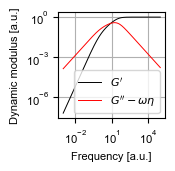

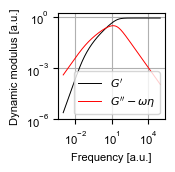

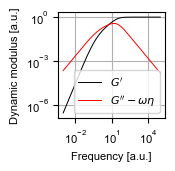

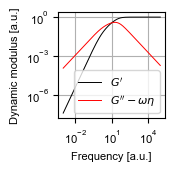

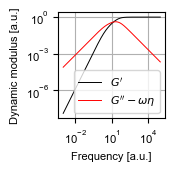

In [11]:
#fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
#ax1 = fig.add_subplot(111)
for i in range(len(storage_mod_sp)):
    fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
    ax1 = fig.add_subplot(111)
    
    mean_storage_mod_all_sims_ex1=np.mean(storage_mod_sp[i],axis=0)
    std_e_storage_mod_all_sims_ex1=np.std(storage_mod_sp[i],axis=0)/(np.sqrt(len(storage_mod_sp[i])))
    
    
    mean_loss_mod_all_sims_ex1=np.mean(loss_mod_sp[i],axis=0)
    std_e_loss_mod_all_sims_ex1=np.std(loss_mod_sp[i],axis=0)/(np.sqrt(len(loss_mod_sp[i])))
    
    ax1.errorbar(omega_t_sim1[::],mean_storage_mod_all_sims_ex1[::],fmt="-",label=r"$G'$",color="black",linewidth=0.7)
    ax1.fill_between(omega_t_sim1[::], mean_storage_mod_all_sims_ex1[::] + std_e_storage_mod_all_sims_ex1[::], mean_storage_mod_all_sims_ex1[::] - std_e_storage_mod_all_sims_ex1[::], alpha = 0.3 ,facecolor="black")
    
    
    ax1.errorbar(omega_t_sim1[::],mean_loss_mod_all_sims_ex1[::],fmt="-",label=r"$G''-\omega \eta$",color="red",linewidth=0.7)
    ax1.fill_between(omega_t_sim1[::], mean_loss_mod_all_sims_ex1[::] + std_e_loss_mod_all_sims_ex1[::], mean_loss_mod_all_sims_ex1[::] - std_e_loss_mod_all_sims_ex1[::], alpha = 0.3 ,facecolor="red")

    fs1=8
    plt.xscale("log")
    plt.yscale("log")
    plt.grid()
    #plt.ylim(10**-6,2)
    #plt.xlim(10**-3,10**3)
    plt.xticks([10**-2,10**1,10**4],fontname = "Arial",fontsize=fs1)
    plt.yticks([10**-6,10**-3,10**0],fontname = "Arial",fontsize=fs1)
    #plt.xticks([10**-2,10**0,10**2],fontname = "Arial",fontsize=fs1)
    #plt.yticks([10**-6,10**-4,10**-2,10**0],fontname = "Arial",fontsize=fs1)
    ax1.set_ylabel("Dynamic modulus [a.u.]",fontname = "Arial",fontsize=fs1)
    ax1.set_xlabel("Frequency [a.u.]",fontname = "Arial",fontsize=fs1)
    ax1.legend(prop={'family': 'Arial','size': fs1},loc="lower right")
    #if i ==1:
        #save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/target_dyn_mod_ub_rate_0_005_1.pdf"
        #plt.savefig(save_name_1,format="pdf",bbox_inches="tight")

In [12]:
def fit_sp(target_loss_mod,target_storage_mod,loss_mod,storage_mod):
    msd_log_loss_mod=np.sqrt(np.sum( (np.log(target_loss_mod)-np.log(loss_mod))**2 ))
    msd_log_storage_mod=np.sqrt(np.sum( (np.log(target_storage_mod)-np.log(storage_mod))**2 ))
    fit=1/(1+msd_log_loss_mod+msd_log_storage_mod)
    return fit

def fit_sp2(target_loss_mod,target_storage_mod,loss_mod,storage_mod):
    msd_log_loss_mod=np.sqrt(np.sum( (target_loss_mod-loss_mod)**2 ))
    msd_log_storage_mod=np.sqrt(np.sum( (target_storage_mod-storage_mod)**2 ))
    fit=1/(1+msd_log_loss_mod+msd_log_storage_mod)
    return fit

In [13]:
fit_sp_training=np.array([fit_sp2(target_loss_mod_sp,target_storage_mod_sp,training_loss_mod_sp[i],training_storage_mod_sp[i]) for i in range(len(training_storage_mod_sp))])
print(fit_sp_training)

[0.23171969 0.48940736 0.63278926 0.36553711]


In [14]:
fit_sp_target=fit_sp2(target_loss_mod_sp,target_storage_mod_sp,target_loss_mod_sp,target_storage_mod_sp)

print(fit_sp_target)

1.0


In [17]:
x_train=training_mean_fused_linkers  #np.log(np.array(training_split_rate[2:4]))
y_train=fit_sp_training   #[2:4]

mean_fused_linkers_pred,  gpr_sp=apply_gp_bo_sp(x=x_train,f=y_train,seed=1,dim_x=1,dim_y=1,num_restarts=100,raw_samples=1000)

print(mean_fused_linkers_pred)


[0.72068006]


In [18]:
import torch

gpr_sp.eval()


X_test = torch.linspace(x_train[0], x_train[-1], 200).unsqueeze(-1)  # shape: [n_eval, d]
X_test_np = X_test.detach().cpu().numpy()
X_test_l=[X_test_np[e][0] for e in range(len(X_test_np))]
X_test_l=np.array(X_test_l)
with torch.no_grad():

    posterior = gpr_sp.posterior(X_test, observation_noise=False)

    mean = posterior.mean          # shape: [n_eval, m] for m outputs (m = dim_y), or [n_eval] if m==1
    variance = posterior.variance  # same shape as mean
    std = variance.sqrt()

mean_l=[mean[e][0] for e in range(len(mean))]
mean_l=np.array(mean_l)
variance_l=[variance[e][0] for e in range(len(variance))]
variance_l=np.array(variance_l)
std_l=[std[e][0] for e in range(len(std))]
std_l=np.array(std_l)

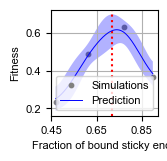

In [19]:
fig1=plt.figure(figsize=(3.5/2.54,3.5/2.54))
#fig1=plt.figure(figsize=(9/2.54 *0.4,3.5/2.54 *0.4))
#fig1=plt.figure(figsize=(9/2.54 ,3.5/2.54 ))

ax1 = fig1.add_subplot(111)

plt.scatter(x_train,y_train,color="grey",label="Simulations",s=10)


ax1.errorbar(X_test_l,mean_l,color="blue",label="Prediction",linewidth=0.7)
#ax1.fill_between(X_test_l, mean_l + variance_l, mean_l - variance_l, alpha = 0.3 ,facecolor="black")
ax1.fill_between(X_test_l, mean_l + std_l, mean_l - std_l, alpha = 0.3 ,facecolor="blue")

#plt.axvline(0.0001)
#plt.axvline(target_mean_fused_linkers,color="grey",label="Target")
#ax1.axvline(mean_fused_linkers_pred,linestyle=":",color="red",label="Predicted optimum")
ax1.axvline(mean_fused_linkers_pred,linestyle=":",color="red")

fs1=8
#plt.xscale("log")
#plt.yscale("log")
plt.grid()
'''plt.xlim(0,4)
plt.ylim(0,20)
plt.xticks([0,2,4],fontname = "Arial",fontsize=fs1)
plt.yticks([0,10,20],fontname = "Arial",fontsize=fs1)'''
plt.xticks([0.45,0.65,0.85],fontname = "Arial",fontsize=fs1)
plt.yticks([0.2,0.4,0.6],fontname = "Arial",fontsize=fs1)
ax1.set_ylabel("Fitness",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Fraction of bound sticky ends",fontname = "Arial",fontsize=fs1)
ax1.legend(loc="lower center",prop={'family': 'Arial','size': fs1})


save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/bayes_opt_split_rate_2.pdf"

#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")

# BO using theoretical graphs for training

In [20]:
#generate theoretical graphs for training data
omega_t_len_s=np.geomspace(10**-3,10**5,10**3) #geomspace(10**2,10**10,10**3)
t_len_s=np.geomspace(10**-2,10**3,10**3)

add_nodes=np.arange(66,201,2)
bound_fraction_add_nodes=add_nodes/200

storage_mod_theo_train=[]
loss_mod_theo_train=[]
relaxation_mod_theo_train=[]
relaxation_time_theo_train=[]
rs_f=0
for k in range(len(add_nodes)):
    storage_mod_theo_train_e=[]
    loss_mod_theo_train_e=[]
    relaxation_mod_theo_train_e=[]
    for i in range(10):
        test_L1=generate_rd_graph_laplacian3(N=100, m=4, p=add_nodes[k], rs=rs_f)
        
        storage_mod_1,loss_mod_1,relaxation_mod_1,relaxation_time_1=get_moduli_from_graph_laplacian4(test_L1,omega_t_len_s,t_len_s)
        
        storage_mod_theo_train_e.append(storage_mod_1)
        loss_mod_theo_train_e.append(loss_mod_1)
        relaxation_mod_theo_train_e.append(relaxation_mod_1)

        relaxation_time_theo_train.append(relaxation_time_1)

        rs_f=rs_f+1

    storage_mod_theo_train.append(storage_mod_theo_train_e)
    loss_mod_theo_train.append(loss_mod_theo_train_e)
    relaxation_mod_theo_train.append(relaxation_mod_theo_train_e)
        


/home/aaron/miniconda3/envs/bayesian_opt_1/lib/python3.9/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/aaron/miniconda3/envs/bayesian_opt_1/lib/python3.9/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0.5, 0, 'Frequency [a.u.]')

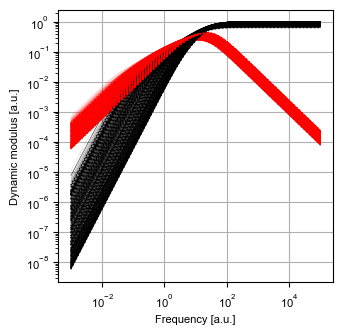

In [21]:
omega_t_len_s=np.geomspace(10**-3,10**5,10**3) #geomspace(10**2,10**10,10**3)
t_len_s=np.geomspace(10**-2,10**3,10**3)
fig1=plt.figure(figsize=(9/2.54,9/2.54))
ax1 = fig1.add_subplot(111)
for i in range(len(storage_mod_theo_train)):
    for j in range(len(storage_mod_theo_train[i])):
        ax1.errorbar(omega_t_len_s,storage_mod_theo_train[i][j],fmt="-",color="black",linewidth=0.2,alpha=0.3)
        ax1.errorbar(omega_t_len_s,loss_mod_theo_train[i][j],fmt="-",color="red",linewidth=0.2,alpha=0.3)


mean_storage_mod_theo_train=np.real(np.mean(storage_mod_theo_train,axis=1))
mean_loss_mod_theo_train=np.real(np.mean(loss_mod_theo_train,axis=1))
mean_relaxation_mod_theo_train=np.real(np.mean(relaxation_mod_theo_train,axis=1))

for i in range(len(mean_storage_mod_theo_train)):
    ax1.errorbar(omega_t_len_s,mean_storage_mod_theo_train[i],fmt=":",color="black",linewidth=1)
    ax1.errorbar(omega_t_len_s,mean_loss_mod_theo_train[i],fmt=":",color="red",linewidth=1)


plt.xscale("log")
plt.yscale("log")
plt.grid()
plt.xticks(fontname = "Arial",fontsize=fs1)
plt.yticks(fontname = "Arial",fontsize=fs1)
ax1.set_ylabel("Dynamic modulus [a.u.]",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Frequency [a.u.]",fontname = "Arial",fontsize=fs1)


In [22]:
add_nodes=np.arange(66,201,20)
print(add_nodes)

[ 66  86 106 126 146 166 186]


In [23]:
len(mean_storage_mod_theo_train)

68

In [24]:
target_storage_mod_theo=mean_storage_mod_sp[0]
target_loss_mod_theo=mean_loss_mod_sp[0]

target_mean_cross_links=np.array(mean_cross_links_sp)[0]/200


fit_theo_training=np.array([fit_sp2(target_loss_mod_theo,target_storage_mod_theo,mean_loss_mod_theo_train[i],mean_storage_mod_theo_train[i]) for i in range(len(mean_loss_mod_theo_train))])


In [25]:
x_train=bound_fraction_add_nodes  #np.log(np.array(training_split_rate[2:4]))
y_train=fit_theo_training   #[2:4]

mean_cross_links_pred,  gpr_sp=apply_gp_bo_sp(x=x_train,f=y_train,seed=1,dim_x=1,dim_y=1,num_restarts=100,raw_samples=1000)

print("target:",target_mean_cross_links)
print("prediction:",mean_cross_links_pred)

target: 0.7047254901960784
prediction: [0.70710872]


In [26]:
target_mean_cross_links

0.7047254901960784

target mean fused SE: 0.713687083888149
target edges +/-sted : 0.7047254901960784 +/- 0.0015726419218560544
prediction edges: 0.7071087171230466


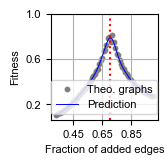

target mean fused SE: 0.46906524633821567
target edges +/-sted : 0.4634509803921569 +/- 0.001990442368610669
prediction edges: 0.45774716573332186


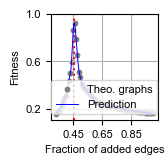

target mean fused SE: 0.6135632490013314
target edges +/-sted : 0.6083725490196078 +/- 0.004165972260475102
prediction edges: 0.5931175390724093


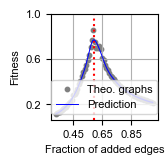

target mean fused SE: 0.7705286284953395
target edges +/-sted : 0.7617450980392156 +/- 0.006520980247708411
prediction edges: 0.7652969876118004


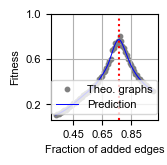

target mean fused SE: 0.8996764314247669
target edges +/-sted : 0.8809999999999999 +/- 0.004331993404761882
prediction edges: 0.8920904639467648


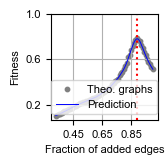

In [27]:
#validation loop

for i in range(len(mean_storage_mod_sp)):
    target_storage_mod_theo=mean_storage_mod_sp[i]
    target_loss_mod_theo=mean_loss_mod_sp[i]
    target_mean_fused_linkers=mean_fused_linkers_sp[i]
    target_mean_cross_links=np.array(mean_cross_links_sp)[i]/200
    target_stde_cross_links=np.array(stde_cross_links_sp)[i]/200

    
    fit_theo_training=np.array([fit_sp2(target_loss_mod_theo,target_storage_mod_theo,mean_loss_mod_theo_train[i],mean_storage_mod_theo_train[i]) for i in range(len(mean_loss_mod_theo_train))])
    x_train=bound_fraction_add_nodes  #np.log(np.array(training_split_rate[2:4]))
    y_train=fit_theo_training   #[2:4]
    
    mean_fused_linkers_pred,  gpr_sp=apply_gp_bo_sp(x=x_train,f=y_train,seed=1,dim_x=1,dim_y=1,num_restarts=100,raw_samples=1000)
    print("target mean fused SE:",target_mean_fused_linkers)
    print("target edges +/-sted :",target_mean_cross_links,"+/-",target_stde_cross_links)
    print("prediction edges:",mean_fused_linkers_pred[0])


    
    gpr_sp.eval()
    
    
    X_test = torch.linspace(x_train[0], x_train[-1], 200).unsqueeze(-1)  # shape: [n_eval, d]
    X_test_np = X_test.detach().cpu().numpy()
    X_test_l=[X_test_np[e][0] for e in range(len(X_test_np))]
    X_test_l=np.array(X_test_l)
    with torch.no_grad():
    
        posterior = gpr_sp.posterior(X_test, observation_noise=False)
    
        mean = posterior.mean          # shape: [n_eval, m] for m outputs (m = dim_y), or [n_eval] if m==1
        variance = posterior.variance  # same shape as mean
        std = variance.sqrt()
    
    mean_l=[mean[e][0] for e in range(len(mean))]
    mean_l=np.array(mean_l)
    variance_l=[variance[e][0] for e in range(len(variance))]
    variance_l=np.array(variance_l)
    std_l=[std[e][0] for e in range(len(std))]
    std_l=np.array(std_l)

    fig1=plt.figure(figsize=(3.5/2.54,3.5/2.54))
    #fig1=plt.figure(figsize=(9/2.54 *0.4,3.5/2.54 *0.4))
    #fig1=plt.figure(figsize=(9/2.54 ,3.5/2.54 ))
    
    ax1 = fig1.add_subplot(111)
    
    plt.scatter(x_train,y_train,color="grey",label="Theo. graphs",s=10)
    
    
    ax1.errorbar(X_test_l,mean_l,color="blue",label="Prediction",linewidth=0.7)
    #ax1.fill_between(X_test_l, mean_l + variance_l, mean_l - variance_l, alpha = 0.3 ,facecolor="black")
    ax1.fill_between(X_test_l, mean_l + std_l, mean_l - std_l, alpha = 0.3 ,facecolor="blue")
    
    #plt.axvline(0.0001)
    #plt.axvline(target_mean_fused_linkers,color="grey",label="Target")
    #ax1.axvline(mean_fused_linkers_pred,linestyle=":",color="red",label="Predicted optimum")
    ax1.axvline(mean_fused_linkers_pred,linestyle=":",color="red")
    
    fs1=8
    #plt.xscale("log")
    #plt.yscale("log")
    plt.grid()
    '''plt.xlim(0,4)
    plt.ylim(0,20)
    plt.xticks([0,2,4],fontname = "Arial",fontsize=fs1)
    plt.yticks([0,10,20],fontname = "Arial",fontsize=fs1)'''
    plt.xticks([0.45,0.65,0.85],fontname = "Arial",fontsize=fs1)
    plt.yticks([0.2,0.6,1.0],fontname = "Arial",fontsize=fs1)
    ax1.set_ylabel("Fitness",fontname = "Arial",fontsize=fs1)
    ax1.set_xlabel("Fraction of added edges",fontname = "Arial",fontsize=fs1)
    ax1.legend(loc="lower center",prop={'family': 'Arial','size': fs1})
    
    #if i ==1:
        #save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/bayes_opt_added_edges_1.pdf"
        #plt.savefig(save_name_1,format="pdf",bbox_inches="tight")
    plt.show()